In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os
print(os.listdir('/kaggle/input'))

['datasets']


In [3]:
import os
print(os.listdir('/kaggle/input/datasets'))

['beautifulminnd']


In [4]:
import os
print(os.listdir('/kaggle/input/datasets/beautifulminnd'))

['tau-urban-acoustic-scenes-2022-mobile-development']


In [5]:
import os
base = '/kaggle/input/datasets/beautifulminnd/tau-urban-acoustic-scenes-2022-mobile-development'
print(os.listdir(base))

['TAU-urban-acoustic-scenes-2022-mobile-development.audio.8', 'TAU-urban-acoustic-scenes-2022-mobile-development.audio.15', 'TAU-urban-acoustic-scenes-2022-mobile-development.audio.1', 'TAU-urban-acoustic-scenes-2022-mobile-development.audio.9', 'TAU-urban-acoustic-scenes-2022-mobile-development.audio.10', 'TAU-urban-acoustic-scenes-2022-mobile-development.audio.5', 'TAU-urban-acoustic-scenes-2022-mobile-development.meta', 'TAU-urban-acoustic-scenes-2022-mobile-development.audio.16', 'TAU-urban-acoustic-scenes-2022-mobile-development.doc', 'TAU-urban-acoustic-scenes-2022-mobile-development.audio.12', 'TAU-urban-acoustic-scenes-2022-mobile-development.audio.2', 'TAU-urban-acoustic-scenes-2022-mobile-development.audio.4', 'TAU-urban-acoustic-scenes-2022-mobile-development.audio.6', 'TAU-urban-acoustic-scenes-2022-mobile-development.audio.3', 'TAU-urban-acoustic-scenes-2022-mobile-development.audio.7', 'TAU-urban-acoustic-scenes-2022-mobile-development.audio.13', 'TAU-urban-acoustic-scene

In [5]:
import glob

base = '/kaggle/input/datasets/beautifulminnd/tau-urban-acoustic-scenes-2022-mobile-development'
wavs = glob.glob(f"{base}/**/audio/*.wav", recursive=True)
print(f"Toplam wav: {len(wavs)}")
print(f"Örnek yol: {wavs[0]}")

Toplam wav: 230350
Örnek yol: /kaggle/input/datasets/beautifulminnd/tau-urban-acoustic-scenes-2022-mobile-development/TAU-urban-acoustic-scenes-2022-mobile-development.audio.8/TAU-urban-acoustic-scenes-2022-mobile-development/audio/park-vienna-104-2962-5-a.wav


In [6]:
import os, glob
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from torch.optim.lr_scheduler import CosineAnnealingLR

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Cihaz: {device}")

✅ Cihaz: cuda


In [11]:
BASE = '/kaggle/input/datasets/beautifulminnd/tau-urban-acoustic-scenes-2022-mobile-development'
META_CSV = f"{BASE}/TAU-urban-acoustic-scenes-2022-mobile-development.meta/TAU-urban-acoustic-scenes-2022-mobile-development/meta.csv"

# Meta CSV'yi oku
meta = pd.read_csv(META_CSV, sep='\t')
meta['fname'] = meta['filename'].apply(os.path.basename)
meta['city']  = meta['fname'].apply(lambda x: x.split('-')[1])
print(f"✅ Meta kayıt: {len(meta)}")

# Wav dosyalarını paket paket tara (daha hızlı)
import os
wav_dict = {}
for item in os.listdir(BASE):
    audio_dir = os.path.join(BASE, item, 'TAU-urban-acoustic-scenes-2022-mobile-development', 'audio')
    if os.path.isdir(audio_dir):
        for f in os.listdir(audio_dir):
            if f.endswith('.wav'):
                wav_dict[f] = os.path.join(audio_dir, f)

print(f"✅ Toplam wav: {len(wav_dict)}")

# Şehre göre train/val böl
VAL_CITIES   = {'barcelona', 'helsinki'}
TRAIN_CITIES = set(meta['city'].unique()) - VAL_CITIES

train_list, val_list = [], []
for _, row in meta.iterrows():
    fname = row['fname']
    if fname not in wav_dict:
        continue
    city  = row['city']
    label = row['scene_label']
    if city in VAL_CITIES:
        val_list.append((wav_dict[fname], label))
    elif city in TRAIN_CITIES:
        train_list.append((wav_dict[fname], label))

unique_labels = sorted(set(l for _, l in train_list + val_list))
label_to_idx  = {label: i for i, label in enumerate(unique_labels)}

print(f"\n🚂 Train: {len(train_list)} | 🔍 Val: {len(val_list)}")
print(f"📋 Sınıflar: {unique_labels}")


def process_audio(audio_path, augment=False):
    waveform, sample_rate = torchaudio.load(audio_path)
    if augment:
        shift = int(sample_rate * 0.05)
        waveform = torch.roll(waveform, shifts=shift, dims=1)
        waveform = waveform * (0.9 + 0.2 * torch.rand(1).item())
    mel_db = T.AmplitudeToDB()(
        T.MelSpectrogram(sample_rate=sample_rate, n_fft=2048, hop_length=512, n_mels=64)(waveform)
    )
    if augment:
        mel_db = T.FrequencyMasking(freq_mask_param=5)(mel_db)
        mel_db = T.TimeMasking(time_mask_param=10)(mel_db)
    input_tensor = nn.functional.interpolate(
        mel_db.unsqueeze(0), size=(224, 224), mode='bilinear', align_corners=False
    ).squeeze(0)
    if input_tensor.shape[0] == 1:
        input_tensor = input_tensor.repeat(3, 1, 1)
    return input_tensor


class TAUDataset(Dataset):
    def __init__(self, data_list, label_to_idx, augment=False):
        self.data_list     = data_list
        self.label_to_idx  = label_to_idx
        self.augment       = augment
        self.unique_labels = list(label_to_idx.keys())

    def __len__(self): return len(self.data_list)

    def __getitem__(self, idx):
        path, label = self.data_list[idx]
        return process_audio(path, self.augment), torch.tensor(self.label_to_idx[label], dtype=torch.long)


train_dataset = TAUDataset(train_list, label_to_idx, augment=True)
val_dataset   = TAUDataset(val_list,   label_to_idx, augment=False)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
print("✅ DataLoader hazır!")

✅ Meta kayıt: 230350
✅ Toplam wav: 230350

🚂 Train: 182510 | 🔍 Val: 47840
📋 Sınıflar: ['airport', 'bus', 'metro', 'metro_station', 'park', 'public_square', 'shopping_mall', 'street_pedestrian', 'street_traffic', 'tram']
✅ DataLoader hazır!


NameError: name 'train_list' is not defined

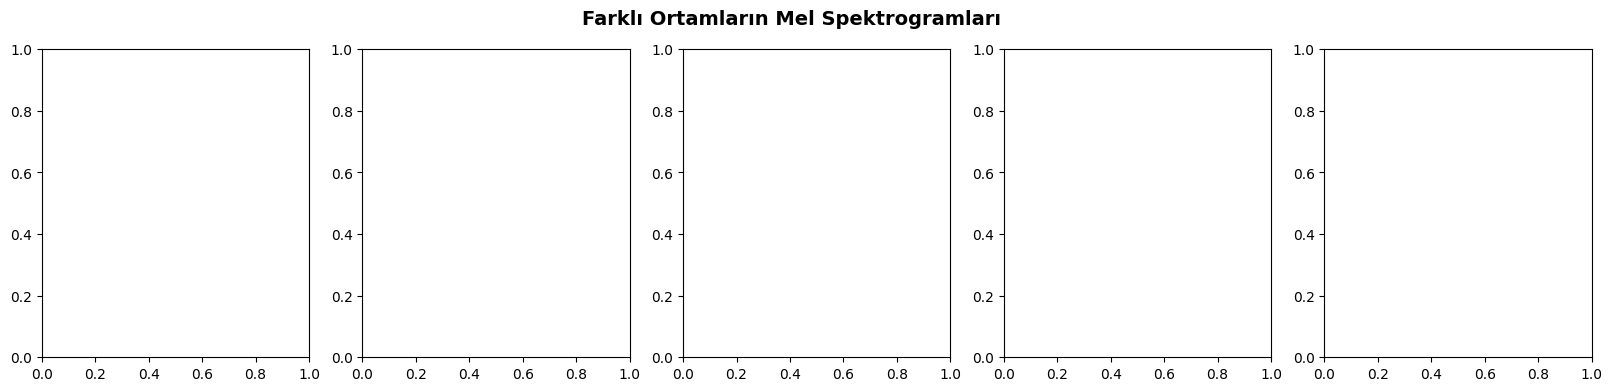

In [8]:
import matplotlib.pyplot as plt

def spektrogram_goster():
    siniflar = ['airport', 'metro', 'park', 'street_traffic', 'bus']
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle('Farklı Ortamların Mel Spektrogramları', fontsize=14, fontweight='bold')
    
    for i, sinif in enumerate(siniflar):
        # O sınıftan bir örnek bul
        ornek = next((path for path, label in train_list if label == sinif), None)
        if ornek is None:
            continue
            
        waveform, sample_rate = torchaudio.load(ornek)
        mel_db = T.AmplitudeToDB()(
            T.MelSpectrogram(sample_rate=sample_rate, n_fft=2048, hop_length=512, n_mels=64)(waveform)
        )
        
        axes[i].imshow(mel_db[0].numpy(), aspect='auto', origin='lower', cmap='viridis')
        axes[i].set_title(sinif.replace('_', '\n'), fontsize=10, fontweight='bold')
        axes[i].set_xlabel('Zaman')
        if i == 0:
            axes[i].set_ylabel('Mel Frekans')
        else:
            axes[i].set_yticks([])
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/spektrogramlar.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Görsel kaydedildi: spektrogramlar.png")

spektrogram_goster()

In [13]:
class MobileNetTransformer(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        mobilenet = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
        self.feature_extractor = mobilenet.features
        self.hidden_dim = 1280
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.hidden_dim, nhead=8, batch_first=True, dropout=0.3
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.classifier = nn.Sequential(
            nn.Linear(self.hidden_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        f = self.feature_extractor(x)
        f = f.mean(dim=2).permute(0, 2, 1)
        return self.classifier(self.transformer(f).mean(dim=1))

model     = MobileNetTransformer(num_classes=len(unique_labels)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.05)
scheduler = CosineAnnealingLR(optimizer, T_max=10)

print(f"✅ Model hazır | Parametre: {sum(p.numel() for p in model.parameters()):,}")
print(f"🖥️  Cihaz: {device}\n")

best_val_acc = 0

for epoch in range(3):  # ← 3 epoch
    model.train()
    correct, total = 0, 0
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        correct += (torch.max(outputs,1)[1] == labels).sum().item()
        total   += labels.size(0)
        if (i+1) % 200 == 0:
            print(f"  Epoch {epoch+1} | Adım {i+1}/{len(train_loader)} | Kayıp: {loss.item():.4f}")
    scheduler.step()

    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            val_correct += (torch.max(model(images),1)[1] == labels).sum().item()
            val_total   += labels.size(0)

    train_acc = 100 * correct / total
    val_acc   = 100 * val_correct / val_total

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/kaggle/working/best_model.pth")
        print(f"  💾 En iyi model kaydedildi!")

    print(f"\n{'='*55}")
    print(f"Epoch {epoch+1:2d}/3 | Train: %{train_acc:.1f} | Val: %{val_acc:.1f} | En iyi: %{best_val_acc:.1f}")
    print(f"{'='*55}\n")

print("🎉 Eğitim tamamlandı!")
print(f"🏆 En iyi val doğruluğu: %{best_val_acc:.1f}")

✅ Model hazır | Parametre: 26,174,986
🖥️  Cihaz: cuda

  Epoch 1 | Adım 200/5704 | Kayıp: 1.8743
  Epoch 1 | Adım 400/5704 | Kayıp: 1.4456
  Epoch 1 | Adım 600/5704 | Kayıp: 1.3998
  Epoch 1 | Adım 800/5704 | Kayıp: 1.5319
  Epoch 1 | Adım 1000/5704 | Kayıp: 1.0300
  Epoch 1 | Adım 1200/5704 | Kayıp: 1.5280
  Epoch 1 | Adım 1400/5704 | Kayıp: 1.4778
  Epoch 1 | Adım 1600/5704 | Kayıp: 0.9104
  Epoch 1 | Adım 1800/5704 | Kayıp: 1.1633
  Epoch 1 | Adım 2000/5704 | Kayıp: 1.4068
  Epoch 1 | Adım 2200/5704 | Kayıp: 1.1736
  Epoch 1 | Adım 2400/5704 | Kayıp: 1.1425
  Epoch 1 | Adım 2600/5704 | Kayıp: 1.4320
  Epoch 1 | Adım 2800/5704 | Kayıp: 0.9598
  Epoch 1 | Adım 3000/5704 | Kayıp: 1.1585
  Epoch 1 | Adım 3200/5704 | Kayıp: 1.4451
  Epoch 1 | Adım 3400/5704 | Kayıp: 0.8970
  Epoch 1 | Adım 3600/5704 | Kayıp: 1.0593
  Epoch 1 | Adım 3800/5704 | Kayıp: 1.2501
  Epoch 1 | Adım 4000/5704 | Kayıp: 0.9554
  Epoch 1 | Adım 4200/5704 | Kayıp: 0.9435
  Epoch 1 | Adım 4400/5704 | Kayıp: 0.9877
  E

In [23]:
def canli_tahmin(dosya_yolu):
    # 1. Modeli değerlendirme moduna al
    model.eval()
    
    try:
        # 2. Ses dosyasını işle (kodundaki mevcut process_audio fonksiyonunu kullanıyoruz)
        # Sesi spektrograma çevirir ve 224x224 boyutuna getirir
        input_tensor = process_audio(dosya_yolu, augment=False)
        input_tensor = input_tensor.unsqueeze(0).to(device) # Batch boyutu ekle ve GPU'ya gönder
        
        # 3. Tahmin yap
        with torch.no_grad():
            output = model(input_tensor)
            tahmin_olasiliklari = torch.nn.functional.softmax(output, dim=1)
            tahmin_idx = torch.argmax(tahmin_olasiliklari, dim=1).item()
            
        # 4. Sonucu yazdır
        tahmin_edilen_sinif = unique_labels[tahmin_idx]
        guven_orani = tahmin_olasiliklari[0][tahmin_idx].item() * 100
        
        print(f"\n🎧 Analiz Edilen Dosya: {os.path.basename(dosya_yolu)}")
        print(f"🤖 Tahmin: {tahmin_edilen_sinif.upper()}")
        print(f"📊 Güven Oranı: %{guven_orani:.2f}")
        
    except Exception as e:
        print(f"❌ Tahmin sırasında bir hata oluştu: {e}")

print("✅ canli_tahmin fonksiyonu başarıyla tanımlandı.")

✅ canli_tahmin fonksiyonu başarıyla tanımlandı.


In [25]:
import torchaudio
import os

# 1. Kopyaladığın tam yolu buraya tanımlıyoruz
ses_dosyasi = "/kaggle/input/datasets/mervedemirciolu/benim-sesim/kafeses.wav"

# Dosya yolunu kontrol edelim (Gereksiz ama hata ayıklamak için iyidir)
if os.path.exists(ses_dosyasi):
    # 2. Sesi yükle
    waveform, sr = torchaudio.load(ses_dosyasi)
    
    # 3. 1 saniyelik kesit al 
    # (Ses 1 saniyeden kısaysa hata vermemesi için min kullandık)
    waveform_1sn = waveform[:, :min(waveform.shape[1], sr)]
    
    # 4. Kesilen sesi Kaggle'ın yazılabilir alanına (working) kaydet
    cikti_yolu = "/kaggle/working/test_1sn.wav"
    torchaudio.save(cikti_yolu, waveform_1sn, sr)
    
    print(f"✅ Başarılı! Ses işlendi. Örnekleme hızı (Sample rate): {sr}")
    
    # 5. Modeline tahmine gönder
    canli_tahmin(cikti_yolu)
else:
    print("❌ Hata: Dosya hala bulunamadı. Lütfen sağ taraftaki 'Data' kısmından yolun değişip değişmediğini kontrol et.")

✅ Başarılı! Ses işlendi. Örnekleme hızı (Sample rate): 44100

🎧 Analiz Edilen Dosya: test_1sn.wav
🤖 Tahmin: AIRPORT
📊 Güven Oranı: %46.56


In [28]:
def canli_tahmin(dosya_yolu):
    model.eval()
    
    try:
        # 1. Ses işle
        input_tensor = process_audio(dosya_yolu, augment=False)
        
        # --- KANAL DÜZELTME BLOĞU ---
        # Eğer giriş 2 kanallıysa (stereo), 3. bir kanal ekleyerek 3'e tamamla
        if input_tensor.shape[0] == 2:
            extra_channel = input_tensor[0:1, :, :] # İlk kanalı kopyala
            input_tensor = torch.cat([input_tensor, extra_channel], dim=0)
        # Eğer hala 1 kanallıysa (bazı durumlarda üstteki işlem gerekebilir)
        elif input_tensor.shape[0] == 1:
            input_tensor = input_tensor.repeat(3, 1, 1)
        # 3 kanaldan fazlaysa (nadir), ilk 3 kanalı al
        input_tensor = input_tensor[:3, :, :]
        # ----------------------------

        input_tensor = input_tensor.unsqueeze(0).to(device)
        
        # 2. Tahmin yap
        with torch.no_grad():
            output = model(input_tensor)
            probs = torch.nn.functional.softmax(output, dim=1)
            tahmin_idx = torch.argmax(probs, dim=1).item()
            
        tahmin_edilen_sinif = unique_labels[tahmin_idx]
        guven_orani = probs[0][tahmin_idx].item() * 100
        
        print(f"\n🎧 Analiz Edilen: {os.path.basename(dosya_yolu)}")
        print(f"🤖 Tahmin: {tahmin_edilen_sinif.upper()}")
        print(f"📊 Güven Oranı: %{guven_orani:.2f}")
        
    except Exception as e:
        print(f"❌ Tahmin sırasında bir hata oluştu: {e}")

print("✅ canli_tahmin fonksiyonu stereo destekleyecek şekilde güncellendi.")

✅ canli_tahmin fonksiyonu stereo destekleyecek şekilde güncellendi.


In [29]:
import torchaudio
import os

# Dosya yolunu tırnak işaretleri arasına almayı unutma:
ses_dosyasi = "/kaggle/input/datasets/mervedemirciolu/parksesi/Park-ambience-sound-_Royalty-Free_-_e_zCM0EobAY_.wav"

if os.path.exists(ses_dosyasi):
    # Sesi yükle ve 1 saniyelik kesit al
    waveform, sr = torchaudio.load(ses_dosyasi)
    waveform_1sn = waveform[:, :min(waveform.shape[1], sr)]
    
    # İşlenen dosyayı kaydet
    test_cikti = "/kaggle/working/park_test_final.wav"
    torchaudio.save(test_cikti, waveform_1sn, sr)
    
    print(f"✅ Park sesi başarıyla işlendi.")
    
    # Modeli test et
    canli_tahmin(test_cikti)
else:
    print("❌ Hata: Dosya yolu hala hatalı görünüyor. Lütfen yolu tırnak içinde yazdığından emin ol.")

✅ Park sesi başarıyla işlendi.

🎧 Analiz Edilen: park_test_final.wav
🤖 Tahmin: PARK
📊 Güven Oranı: %98.61


In [30]:
import torchaudio
import os

# Paylaştığın yeni sokak sesi yolu
yeni_sokak_sesi = "/kaggle/input/datasets/mervedemirciolu/sokaksesi/Street-Sound-Effect-_-High-quality-_9z4K5EdXR-c_.wav"

if os.path.exists(yeni_sokak_sesi):
    print(f"✅ Dosya bulundu, analiz ediliyor...")
    
    # 1 saniyelik kesit alalım (model 1 saniye üzerinden eğitilmiştir)
    waveform, sr = torchaudio.load(yeni_sokak_sesi)
    waveform_1sn = waveform[:, :min(waveform.shape[1], sr)]
    
    # Geçici dosyayı kaydet
    test_yolu = "/kaggle/working/sokak_deneme.wav"
    torchaudio.save(test_yolu, waveform_1sn, sr)
    
    # Güncel tahmin fonksiyonunu çağır (stereo desteği dahil)
    canli_tahmin(test_yolu)
else:
    print("❌ Hata: Dosya yolu bulunamadı. Lütfen sağ paneldeki 'Data' kısmından yolu kopyalayıp tırnak içinde yazdığınızdan emin olun.")

✅ Dosya bulundu, analiz ediliyor...

🎧 Analiz Edilen: sokak_deneme.wav
🤖 Tahmin: METRO_STATION
📊 Güven Oranı: %43.40


In [1]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# En iyi modeli yükle
model.load_state_dict(torch.load("/kaggle/working/best_model.pth"))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        preds = torch.max(model(images), 1)[1].cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(cm, display_labels=unique_labels)
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues')
plt.title("Confusion Matrix — MobileNet + Temporal Transformer\nVal Accuracy: %50.8 (Epoch 3)", fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Kaydedildi!")

# Hangi sınıflar en iyi/kötü
print("\n📊 Sınıf bazlı doğruluk:")
for i, label in enumerate(unique_labels):
    total = cm[i].sum()
    correct = cm[i][i]
    print(f"  {label:20s} → %{100*correct/total:.1f}")

NameError: name 'model' is not defined

In [12]:
class MobileNetTransformer(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        mobilenet = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
        self.feature_extractor = mobilenet.features
        self.hidden_dim = 1280
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.hidden_dim, nhead=8, batch_first=True, dropout=0.3
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.classifier = nn.Sequential(
            nn.Linear(self.hidden_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        f = self.feature_extractor(x)
        f = f.mean(dim=2).permute(0, 2, 1)
        return self.classifier(self.transformer(f).mean(dim=1))

model = MobileNetTransformer(num_classes=len(unique_labels)).to(device)
model.load_state_dict(torch.load("/kaggle/working/best_model.pth"))
print("✅ Model yüklendi!")

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/best_model.pth'